In [1]:
# IMPORTANTE CAMBIO EN LA ARQUITECTURA DEL CÓDIGO (modificación 2do avance):
# Al notar una reiteracion en la estructura de los casos de estudio (cavidad cuadrada para distintos valores de Re y obstaculo circular), se decide iterar sobre una lista de diccionarios, 
# que contenga los parámetros para cada caso, este se encuentra en la celda 12. Mediante este motor de ejecución se obtiene una mayor escalabilidad y organización del código, 
# facilitando la adición o modificación de casos sin alterar la estructura principal del programa. Esto es útil para comparar resultados con diferentes configuraciones y para realizar estudios de convergencia
# o sensibilidad a los parámetros. Además, se implementa un purgado estricto de memoria al finalizar cada caso, eliminando variables y forzando la recolección de basura para liberar RAM. Por ello tanto
# las variables fisicas globales como la inicialización de los campos se encuentran dentro del ciclo de iteración y fueron removidos de esta sección del código. Con esto dicho se continua con lo ya establecido. 

#Se sigue la metodologia usada en "Numerical Simulations in Fluid Dynamics" de M. Griebel en el capitulo 3 "The Numerical Treatment of the Navier—Stokes Equations"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
mpl.rcParams['animation.embed_limit'] = 100.0
import gc  
from numba import njit

In [2]:
# Calculamos los terminos F (u estrella) y G (v estrella) de la etapa predictor usando diferencias finitas y aplicando la forma conservativa de las derivadas parciales para los terminos convectivos. 
# Se incluyen términos de difusión y convección, con mezcla Upwind/Central para estabilidad a Re altos.

# Modificación importante (2do avance):
# Con ayuda de la IA se incorpora JIT de Numba para colapsar el tiempo de computo lo cual será requerido para probar los limites de convergencia al
# comparar con los resultados de ghia et al. para Re altos con mallas grandes (128x128 o 257x257).
# Dado que a diferentes CB se le asignan distintas condiciones a los campos u y v, no era correcto iniciar los campos F y G con ceros (esto solo era válido para el caso de la cavidad, dadas sus condiciones de frontera no slip), 
# pero para el caso del obstaculo circular, al tener condiciones de frontera de tipo inlet y outlet (entra y sale materia), el campo de velocidades no es nulo en la frontera. De este modo las matrices intermedias F y G hereden las condiciones de contorno.
# El resto del código se mantiene igual.
@njit
def calcular_F_G(u, v, nu, dt, dx, dy, gamma, imax, jmax):
    
    F = u.copy()
    G = v.copy()
    # calculo de F
    for i in range(1, imax):
        for j in range(1, jmax + 1):
            # Derivadas de u^2 y uv (Forma Conservativa)
            # Promedios y diferencias para el transporte de momento en X
            du2dx = (1/dx) * ( ((u[i,j] + u[i+1,j])/2)**2 + gamma * abs(u[i,j] + u[i+1,j])/2 * (u[i,j] - u[i+1,j])/2 - 
                               ((u[i-1,j] + u[i,j])/2)**2 - gamma * abs(u[i-1,j] + u[i,j])/2 * (u[i-1,j] - u[i,j])/2 )
            
            duvdy = (1/dy) * ( ((v[i,j] + v[i+1,j])/2) * ((u[i,j] + u[i,j+1])/2) + gamma * abs(v[i,j] + v[i+1,j])/2 * (u[i,j] - u[i,j+1])/2 -
                               ((v[i,j-1] + v[i+1,j-1])/2) * ((u[i,j-1] + u[i,j])/2) - gamma * abs(v[i,j-1] + v[i+1,j-1])/2 * (u[i,j-1] - u[i,j])/2 )

            # Laplaciano de u (Difusión)
            lapl_u = (u[i+1,j] - 2*u[i,j] + u[i-1,j])/dx**2 + (u[i,j+1] - 2*u[i,j] + u[i,j-1])/dy**2
            
            F[i,j] = u[i,j] + dt * (nu * lapl_u - du2dx - duvdy)
    # calculo de G
    for i in range(1, imax + 1):
        for j in range(1, jmax):
            # Derivadas de uv y v^2 (Forma Conservativa)
            duvdx = (1/dx) * ( ((u[i,j] + u[i,j+1])/2) * ((v[i,j] + v[i+1,j])/2) + gamma * abs(u[i,j] + u[i,j+1])/2 * (v[i,j] - v[i+1,j])/2 -
                               ((u[i-1,j] + u[i-1,j+1])/2) * ((v[i-1,j] + v[i,j])/2) - gamma * abs(u[i-1,j] + u[i-1,j+1])/2 * (v[i-1,j] - v[i,j])/2 )
            
            dv2dy = (1/dy) * ( ((v[i,j] + v[i,j+1])/2)**2 + gamma * abs(v[i,j] + v[i,j+1])/2 * (v[i,j] - v[i,j+1])/2 -
                               ((v[i,j-1] + v[i,j])/2)**2 - gamma * abs(v[i,j-1] + v[i,j])/2 * (v[i,j-1] - v[i,j])/2 )

            # Laplaciano de v
            lapl_v = (v[i+1,j] - 2*v[i,j] + v[i-1,j])/dx**2 + (v[i,j+1] - 2*v[i,j] + v[i,j-1])/dy**2
            
            G[i,j] = v[i,j] + dt * (nu * lapl_v - duvdx - dv2dy)
    return F, G



In [3]:
# Con este campo de velocidades "estrella" u*=(F,G) nos es simple reconocer la descomposicion de Helmholtz-Hodge a usar para resolver nuestro problema (pag 33 del libro de M. Griebel)
# en done el campo solenoidal u^(n+1) se obtiene de la resta del campo (F,G) con el gradiente de un potencial escalar (la preison p). [u^(n+1) = u* - grad(p)]
# Luego aplicando la divergencia a la descomposicion obtenemos la ecuacion de Poisson para la presion, con el lado derecho dado por la divergencia de u*=(F,G). [lapl(p) = div(F,G) = rhs_poisson]
# definimos entonces la funcion para calcular el lado derecho de la ec de poisson

@njit
def calcular_rhs_poisson(F, G, dt, dx, dy, rho, imax, jmax):
    
    rhs_poisson = np.zeros((imax + 2, jmax + 2))
    for i in range(1, imax + 1):
        for j in range(1, jmax + 1):
            rhs_poisson[i,j] = (rho / dt) * ( (F[i,j] - F[i-1,j])/dx + (G[i,j] - G[i,j-1])/dy )
    return rhs_poisson


In [4]:
# Con el lado derecho de la ec de poisson listo, ahora escribimos el lado izq (laplaciano) mediante diferencias finitas centradas y resolvemos la ecuacion de poisson para la presion usando
# el metodo iterativo de gauss-seidel con SOR para acelerar la convergencia. Para ello debemos despejar la presion p[i,j] en terminos de sus vecinos y el lado derecho rhs_poisson[i,j].

# Modificación importante (2do avance):
# Al igual que antes se implementa JIT de Numba para acelerar el tiempo de computo, además se generalizó las condiciones de contorno para la 
# presión: mientras que la cavidad opera bajo un esquema puramente Neumann, el canal con obstáculo requiere una condición de Dirichlet antisimétrica en la 
# salida para fijar una referencia de presurización y asegurar la convergencia del algoritmo SOR

@njit
def solver_poisson_SOR(p, rhs_poisson, dx, dy, omega, eps, iter_max, imax, jmax, flag_geometria):
    
    
    p_viejo = np.empty_like(p) 
    dx2 = dx**2
    dy2 = dy**2
    denominador = 2.0 * (1.0/dx2 + 1.0/dy2)
    
    for it in range(iter_max):
        
        p_viejo[:] = p[:]
        
        # 1. Barrido SOR (Nodos internos)
        for i in range(1, imax + 1):
            for j in range(1, jmax + 1):
                p_nuevo = (1.0 / denominador) * ( (p[i+1, j] + p[i-1, j]) / dx2 + (p[i, j+1] + p[i, j-1]) / dy2 - rhs_poisson[i, j] )
                p[i,j] = (1.0 - omega) * p[i,j] + omega * p_nuevo
                
        # 2. Imposición de Condiciones de Borde Neumann (dp/dn = 0) menos en la salida (cara derecha) del canal con obstáculo donde se impone Dirichlet antisimétrico para asegurar convergencia.
        if flag_geometria == 0:  # Cavidad
            p[0, 1:jmax+1] = p[1, 1:jmax+1]
            p[imax+1, 1:jmax+1] = p[imax, 1:jmax+1]
            p[1:imax+1, 0] = p[1:imax+1, 1]
            p[1:imax+1, jmax+1] = p[1:imax+1, jmax]
            
        elif flag_geometria == 1:  # Obstáculo
            p[0, 1:jmax+1] = p[1, 1:jmax+1]           
            p[1:imax+1, 0] = p[1:imax+1, 1]           
            p[1:imax+1, jmax+1] = p[1:imax+1, jmax]   
            p[imax+1, 1:jmax+1] = -p[imax, 1:jmax+1]  # Salida Dirichlet

        # 3. Cálculo de Residuo para Condición de Corte
        residuo_max = 0.0
        for i in range(1, imax + 1):
            for j in range(1, jmax + 1):
                diff = abs(p[i,j] - p_viejo[i,j])
                if diff > residuo_max:
                    residuo_max = diff
                    
        # Condición de corte
        if residuo_max < eps:
            return p, it + 1, residuo_max
            
    return p, iter_max, residuo_max

In [5]:
# Finalmente, con la presion calculada, procedemos a actualizar los campos de velocidades solenoidales (correcion solenoidal) usando la relación u^(n+1) = u* - dt*grad(p)/rho. 
# Para esto, simplemente restamos el gradiente de la presión a los campos F y G para obtener las velocidades actualizadas u y v.


@njit
def corrector_solenoidal(u, v, F, G, p, dt, dx, dy, rho, imax, jmax):
    # Actualizamos u (Caras verticales: i=1..imax-1, j=1..jmax)
    for i in range(1, imax):
        for j in range(1, jmax + 1):
            # Gradiente de presión en X
            dp_dx = (p[i+1, j] - p[i, j]) / dx
            u[i, j] = F[i, j] - (dt / rho) * dp_dx
            
    # Actualizamos v (Caras horizontales: i=1..imax, j=1..jmax-1)
    for i in range(1, imax + 1):
        for j in range(1, jmax):
            # Gradiente de presión en Y
            dp_dy = (p[i, j+1] - p[i, j]) / dy
            v[i, j] = G[i, j] - (dt / rho) * dp_dy
            
    return u, v

In [6]:
# Con el campo de velocidades (u,v) corregido y listo para usar, planteamos las condiciones de borde para las situaciones pedidas.Partimos por las CB de la caja cuadrada, usando la condicion de no deslizamiento
# (no-slip condition, pag 30 del libro de M. Griebel), que establece 0 a las velocidades perpendiculaes a las poredes fijas y calcula el promedio de las velocidades tangenciales
# de modo que entre un paso antes y un paso despues de la pared, la velocidad tangencial sea 0. Para la tapa movil, se establece una velocidad tangencial constante (u=3) y se calcula el promedio con la velocidad del paso anterior para mantener la estabilidad.

def CB_cavidad_cuadrada(u, v, imax, jmax, u_tapa=1.0):
    # 1. Velocidades perpendiculares
    for j in range(1, jmax + 1):
        u[0, j] = 0.0          # Pared Izquierda
        u[imax, j] = 0.0       # Pared Derecha
        
    for i in range(1, imax + 1):
        v[i, 0] = 0.0          # Pared Inferior
        v[i, jmax] = 0.0       # Pared Superior
        
    # 2. Velocidades tangenciales (No slip)
    for j in range(1, jmax + 1):
        v[0, j] = -v[1, j]             # Promedio de v da 0 en la pared izquierda
        v[imax+1, j] = -v[imax, j]     # Promedio de v da 0 en la pared derecha

    for i in range(1, imax + 1):
        u[i, 0] = -u[i, 1]             # promedio de u da 0 en la pared inferior
        u[i, jmax+1] = 2.0*u_tapa - u[i, jmax] # promedio de u da u_tapa en la pared superior
        
    return u, v

In [7]:
# Para las CB del canal con obstáculo, se impone un perfil de velocidad parabólico en la entrada, diferencias finitas hacia atrás de primer orden en la salida (condiciones outflow)
# y no-slip en las componentes tangenciales de las paredes. Además de considerar condiciones inflow en la cara izquierda. En la página 31 del libro Griebel et al. se describe a detalle estos casos de contorno.
# Para el cilindro, implementamos una máscara topológica basada en el Método de Frontera Inmersa (IBM) que detecta analíticamente qué caras de la 
# grilla MAC caen dentro del sólido y las fuerza rígidamente a velocidad cero. 

def CB_canal_obstaculo(u, v, imax, jmax, dx, dy, u_in=1.0, xc=0.3, yc=0.48, R=0.1):
    
    # Pared Inferior
    v[:, 0] = 0.0
    u[:, 0] = -u[:, 1]
    
    # Pared Superior
    v[:, jmax] = 0.0
    u[:, jmax+1] = -u[:, jmax]
    
    # Pared Izquierda - Perfil de velocidad parabólico (Poiseuille) para simular un flujo plenamente desarrollado en la entrada
    Ly = jmax*dy
    y_u = np.linspace(0.5 * dy, Ly - 0.5 * dy, jmax)
    u[0, 1:jmax+1] = 4.0 * u_in * y_u * (Ly - y_u) / Ly**2
    v[0, :] = -v[1, :]  # Tangencial nula
    
    # Pared Derecha - Diferencias finitas hacia atrás
    u[imax, :] = u[imax-1, :]
    v[imax+1, :] = v[imax, :]
    
    # Generación de matrices de coordenadas colocalizadas a las caras MAC
    # Indexación 'ij' preserva la estructura matricial de NumPy
    y_u = (np.arange(jmax + 2) - 0.5) * dy
    x_u = np.arange(imax + 1) * dx
    X_u, Y_u = np.meshgrid(x_u, y_u, indexing='ij')
    
    y_v = np.arange(jmax + 1) * dy
    x_v = (np.arange(imax + 2) - 0.5) * dx
    X_v, Y_v = np.meshgrid(x_v, y_v, indexing='ij')
    
    mascara_u_cilindro = (X_u - xc)**2 + (Y_u - yc)**2 <= R**2
    mascara_v_cilindro = (X_v - xc)**2 + (Y_v - yc)**2 <= R**2
    
    u[mascara_u_cilindro] = 0.0
    v[mascara_v_cilindro] = 0.0
    
    return u, v

In [8]:
# Para el posterior analsiis de resultados mediante perfiles de velocidad y campos de vorticidad, se implementa la función para calcular el campo escalar de vorticidad,
# definido matemáticamente como el rotor del campo de velocidades bidimensional (w=dv/dx - du/dy). Debido a la naturaleza de la malla escalonada, las derivadas cruzadas
# ubican de forma natural a la vorticidad en los vértices geométricos de las celdas. Es decir, no es  necesario realizar interpolaciones adicionales para evaluar la 
# vorticidad (usando matrices de coordenadas colocalizadas en las caras MAC).

@njit
def calcular_vorticidad(u, v, dx, dy, imax, jmax):
    
    omega = np.zeros((imax + 1, jmax + 1))
    for i in range(1, imax):
        for j in range(1, jmax):
            dv_dx = (v[i+1, j] - v[i, j]) / dx
            du_dy = (u[i, j+1] - u[i, j]) / dy
            omega[i, j] = dv_dx - du_dy
    return omega

In [ ]:
# Con todo listo, ahora iniciamos el ciclo principal de la simulacion en donde se siguen los pasos del metodo de proyeccion de Chorin: 1- Imponer condiciones de borde, 2- Predictor (Calcular F y G),
# 3- Calcular lado derecho de Poisson, 4- Resolver Poisson para la presion, 5- Corrector Solenoidal y obtener el campo de velocidades real y actualizado para el siguiente paso de tiempo.
# Además, se incluye una etapa crucial de re-imposición de las condiciones de frontera para el caso del canal con obstáculo, ya que el corrector solenoidal introduce un gradiente de presión que puede generar velocidades ficticias dentro del sólido, por lo que se debe anular nuevamente la velocidad en el sólido.
# Finalmente, se captura el historial de los campos de velocidades y vorticidad cada cierto número de pasos para su posterior análisis y visualización.  

def simular_navier_stokes(Re, geometria, nt, dt, imax, jmax, Lx, Ly, u_ref, 
                          gamma, omega, eps, iter_max, paso_guardado):
    
    # Parámetros derivados que varian a cada caso
    nu = u_ref * Lx / Re  # Asumiendo Lx como longitud característica
    dx = Lx / imax
    dy = Ly / jmax
    rho = 1.0

    flag_geom = 0 if geometria == 'cavidad' else 1

    xc, yc, R = Lx/4, Ly/1.9, Ly/8
    
    if flag_geom == 0:
            Re_D = (Re * 2 * R )/Lx
            nu = u_ref * 2 * R / Re_D # Para el caso del obstáculo, la longitud característica es el diámetro del cilindro (2*R), por lo que se recalcula el número de Reynolds y la viscosidad cinemática en consecuencia. 
    else:
        nu = u_ref * Lx / Re
    
    #inicializamos los campos de velocidad, presión y el término fuente para la ecuación de Poisson. Se usan dimensiones ligeramente mayores para acomodar las condiciones de frontera usando "celdas fantamas"

    u = np.zeros((imax + 1, jmax + 2)) # vive en las paredes verticales de la malla, por eso para imax cuadros de la malla hay imax+1 caras verticales
    v = np.zeros((imax + 2, jmax + 1)) # lo opuesto a u, este vive en las caras horizontales
    p = np.zeros((imax + 2, jmax + 2))  # +2 en ambas dimensiones para acomodar las condiciones de frontera, u y v estan alineados en el eje y e x respectivamente a p. por ello tienen dimensiones j+2 e imax+2 respectivamente

    # Buffers de memoria para la posterior captura de datos y visualización de resultados. Se guardan cada "paso_guardado" pasos para no saturar la memoria RAM, pero tener suficiente resolución temporal para analizar la evolución de los campos.
    historial_u = []
    historial_v = []
    historial_vorticidad = []

    # Se inyecta esta perturbación inicial únicamente en el campo transversal v para romper la simetría del momento y gatillar la formación de la estela de von Kármán.
    if geometria == 'obstaculo':
        ruido = 0.05 * u_ref * (np.random.rand(imax + 2, jmax - 1) - 0.5)
        v[:, 1:jmax] += ruido
    
    
    # Ciclo Temporal en el que se implementa el método de proyección de Chorin considerando distintas geometrías y CB
    for n in range(nt):
        
        # 1.
        if geometria == 'cavidad':
            u, v = CB_cavidad_cuadrada(u, v, imax, jmax, u_tapa=u_ref)
        elif geometria == 'obstaculo':
            # Asumimos que para el canal el obstáculo está en x=Lx/4, y=Ly/2 con R=Ly/10
            u, v = CB_canal_obstaculo(u, v, imax, jmax, dx, dy, 
                                      u_in=u_ref, xc=xc, yc=yc, R=R)
            
        # 2.
        F, G = calcular_F_G(u, v, nu, dt, dx, dy, gamma, imax, jmax)
        
        # 3.
        rhs_poisson = calcular_rhs_poisson(F, G, dt, dx, dy, rho, imax, jmax)
        
        # 4.
        # ya que este paso es el cuello de botella computacional, se imprime un mensaje cada 500 pasos para monitorear la convergencia del método iterativo de SOR y 
        # asegurarnos que no se estan alcanzando los límites de iteración sin convergencia, lo cual podría indicar la necesidad de ajustar el parámetro de relajación omega o 
        # revisar las condiciones de frontera para la presión.
        p, it_poisson, res_poisson = solver_poisson_SOR(p, rhs_poisson, dx, dy, omega, eps, iter_max, imax, jmax, flag_geom)
        
        if n == 500:
            if it_poisson == iter_max:
                print(f"Paso {n}: Límite SOR alcanzado. Residuo = {res_poisson:.5f}")
            else:
                print(f"Paso {n}: Poisson convergió en {it_poisson} iteraciones.")
        # 5.
        u, v = corrector_solenoidal(u, v, F, G, p, dt, dx, dy, rho, imax, jmax)

        # El corrector introduce un gradiente de presión que puede generar velocidades 
        # ficticias dentro del cilindro. Se debe anular nuevamente la velocidad en el sólido.
        if flag_geom == 1:
            u, v = CB_canal_obstaculo(u, v, imax, jmax, dx, dy, 
                                      u_in=u_ref, xc=xc, yc=yc, R=R)

        # se almacenan los datos cada "paso_guardado" (a conveniencia para cada caso) pasos para posterior análisis y visualización.
        if n % paso_guardado == 0:
            historial_u.append(u.copy())
            historial_v.append(v.copy())
            historial_vorticidad.append(calcular_vorticidad(u, v, dx, dy, imax, jmax))
            
        if n > 0 and n % 1000 == 0:
            print(f"  -> Progreso: {n}/{nt} pasos temporales computados.")
            
    print(f"Simulación finalizada exitosamente para {geometria.upper()}.")
    return u, v, p, historial_u, historial_v, historial_vorticidad


In [10]:
# Con los datos guardados en los historiales u, v y vorticidad, se procede a la visualización de los resultados. Para ello se crean 2 funciones según lo pedido. Primero
# se Desarrolla la función encargada de compilar la evolución transitoria del flujo en un archivo de video. Utilizando la clase FuncAnimation y el codificador externo FFmpeg, 
# la rutina opera bajo un enfoque de renderizado diferencial que modifica dinámicamente los punteros de datos en cada fotograma sobre una grilla unificada, 
# evitando la destrucción y recreación de figuras en memoria. Dado que esta parte es solo para visualizar, esta grilla no es igual de precisa que la usada para el obstáculo, 
# ya que esta se basa en los centros geométricos de las celdas (grilla colocalizada) y no en las caras MAC, pero es suficiente para apreciar la evolución general del flujo y 
# la formación de estructuras vorticidad.

def exportar_animacion(historial_u, historial_v, historial_vorticidad, Re, geometria, Lx, Ly, imax, jmax, dx, dy):
    
    # A continuación, se prepara la visualización animada de los resultados. Mediante dos subplots, uno para la vorticidad y otro para el campo de velocidades, 
    # se crean objetos gráficos base (heatmap para vorticidad y quiver para velocidades) que serán actualizados en cada frame de la animación. Gran parte de la lógica de la celda 
    # fue realizada con ayuda de IA ya que no tenía experiecnia previa en animaciones.
    
    fig, (ax_vort, ax_vel) = plt.subplots(1, 2, figsize=(15, 5))

    ax_vort.set_aspect('equal', adjustable='box')
    ax_vel.set_aspect('equal', adjustable='box')

    # Se emplea la grilla colocalizada rigurosa (centros geométricos) para ambos gráficos
    # meshgrid() transforma vectores unidimensionales de coordenadas en matrices cartesianas bidimensionales
    x_fisico = np.linspace(dx/2, Lx - dx/2, imax)
    y_fisico = np.linspace(dy/2, Ly - dy/2, jmax)
    X_centros, Y_centros = np.meshgrid(x_fisico, y_fisico)

    # Inicializamos el gráfico de vorticidad usando imshow() que mapea una matriz 2D a una imagen (heatmap)
    # aqui .T traspone las matrices para que estas se alineen correctamente con las coordenadas X_centros y Y_centros.
    # ya que numpy tiene indexación equivalente a (y,x) para matrices, mientras que en gráficos se espera (x,y)
    ax_vort.set_title(f'Campo Escalar de Vorticidad ($Re={Re}$)')
    ax_vort.set_xlim([0, Lx])
    ax_vort.set_ylim([0, Ly])
    omega_final = historial_vorticidad[-1][1:imax+1, 1:jmax+1] 
    vort_limite = np.percentile(np.abs(omega_final), 98)
    
    # Adaptación topológica: Se extraen los nodos internos (imax, jmax) de la matriz de vorticidad para emparejar con la malla unificada X_centros
    im_vort = ax_vort.imshow(historial_vorticidad[0][1:imax+1, 1:jmax+1].T, extent=[0, Lx, 0, Ly], 
                             origin='lower', cmap='RdBu_r', 
                             vmin=-vort_limite, vmax=vort_limite, interpolation='bilinear')
    fig.colorbar(im_vort, ax=ax_vort, fraction=0.046, pad=0.04, extend='both')

    # Inicializamos el gráfico del campo de velocidades usando quiver() el cual mediante las matrices de orgien cartesianas 
    # (X_centros, Y_centros) y las componentes de velocidad promedio a los centros (u_centroide, v_centroide) crea un campo 
    # vectorial de flechas que representan la dirección y magnitud de la velocidad en cada punto del dominio.
    ax_vel.set_title('Dinámica del Campo de Velocidades')
    ax_vel.set_xlim([0, Lx])
    ax_vel.set_ylim([0, Ly])
    #se aplica un submuestreo (cada s puntos) para saturar el gráfico de flechas en mallados grandes y mejorar la visualización
    s = 3 
    u_centroide = (historial_u[0][1:imax+1, 1:jmax+1] + historial_u[0][:imax, 1:jmax+1]) / 2.0
    v_centroide = (historial_v[0][1:imax+1, 1:jmax+1] + historial_v[0][1:imax+1, :jmax]) / 2.0
    quiver_vel = ax_vel.quiver(X_centros[::s, ::s], Y_centros[::s, ::s], 
                           u_centroide.T[::s, ::s], v_centroide.T[::s, ::s], 
                           scale=25, width=0.003, pivot='mid', color='black')

    # esta función se encarga de actualizar los objetos gráficos (im_vort para la vorticidad y quiver_vel 
    # para el campo de velocidades) en cada frame de la animación. Con esto se modifican los punteros de 
    # datos de los objetos preexistentes en lugar de destruir y recrear figuras.La función es invocada internamente por la clase FuncAnimation
    # la cual inyecta el entero iterativo idx correspondiente al tiempo discreto de la simulación
    def renderizar_frame(idx):
        matriz_omega = historial_vorticidad[idx][1:imax+1, 1:jmax+1]
        im_vort.set_data(matriz_omega.T)
        
        matriz_u = historial_u[idx]
        matriz_v = historial_v[idx]
        u_c = (matriz_u[1:imax+1, 1:jmax+1] + matriz_u[:imax, 1:jmax+1]) / 2.0
        v_c = (matriz_v[1:imax+1, 1:jmax+1] + matriz_v[1:imax+1, :jmax]) / 2.0
        u_sub = u_c.T[::s, ::s]
        v_sub = v_c.T[::s, ::s]
        quiver_vel.set_UVC(u_sub, v_sub)
        
        return im_vort, quiver_vel

    ani = FuncAnimation(fig, renderizar_frame, frames=len(historial_u), interval=50, blit=False)

    nombre_video = f"Animacion_{geometria}_Re{Re}.mp4"
    print(f"Compilando {nombre_video} con ffmpeg....")
    ani.save(nombre_video, writer='ffmpeg', fps=30)
    plt.close(fig)
    print("Animación compilada y guardada exitosamente.")

In [11]:
# Luego se crea la función que superpone el mapa de calor continuo de la vorticidad con las líneas de corriente continuas calculadas por integración mediante la función streamplot() de Matplotlib, 
# la cual traza líneas de corriente que representan la trayectoria que seguiría una partícula de fluido en el campo de velocidades. Para esto se usa la misma grilla colocalizada que antes y se 
# promedia el campo de velocidades en las caras para obtener las velocidades en los centros geométricos.

def generar_graficos_estaticos(u, v, historial_vorticidad, Re, geometria, Lx, Ly, imax, jmax, dx, dy):


    # misma grilla colocalizada que para la animación
    x_fisico = np.linspace(dx/2, Lx - dx/2, imax)
    y_fisico = np.linspace(dy/2, Ly - dy/2, jmax)
    X_centros_estatico, Y_centros_estatico = np.meshgrid(x_fisico, y_fisico)

    u_estacionario = np.zeros((imax, jmax))
    v_estacionario = np.zeros((imax, jmax))

    # Promediado de las caras de cada celda de volumen de control
    for i in range(1, imax + 1):
        for j in range(1, jmax + 1):
            u_estacionario[i-1, j-1] = 0.5 * (u[i, j] + u[i-1, j])
            v_estacionario[i-1, j-1] = 0.5 * (v[i, j] + v[i, j-1])

    # Recorte topológico de la vorticidad final calculada en el bucle principal
    # La función calcular_vorticidad retorna dimensiones (imax+1, jmax+1).
    # Se extraen los nodos internos (imax, jmax) para emparejar con la matriz espacial.
    omega_final = historial_vorticidad[-1][1:imax+1, 1:jmax+1]

    fig_estatica, ax_estatico = plt.subplots(figsize=(10, 8))
    ax_estatico.set_aspect('equal', adjustable='box')

    # Mapeo escalar térmico de la vorticidad
    vort_limite = np.percentile(np.abs(omega_final), 98)
    heatmap = ax_estatico.imshow(omega_final.T, extent=[0, Lx, 0, Ly], origin='lower',
                                 cmap='RdBu_r', vmin=-vort_limite, vmax=vort_limite, 
                                 interpolation='bilinear')

    cbar = fig_estatica.colorbar(heatmap, ax=ax_estatico, orientation='horizontal', fraction=0.05, pad=0.15, shrink=0.6, extend='both')
    cbar.set_label(r'Vorticidad $\omega$', fontsize=12)

    # lineas de corrientes calculadas por integración mediante streamplot()
    ax_estatico.streamplot(X_centros_estatico, Y_centros_estatico, 
                           u_estacionario.T, v_estacionario.T, 
                           color='black', density=1.5, linewidth=1.2, arrowsize=1.2)

    ax_estatico.set_title(f'($Re={Re}$) | Malla [{imax}x{jmax}]', fontsize=14)
    ax_estatico.set_xlabel('X (m)')
    ax_estatico.set_ylabel('Y (m)')
    ax_estatico.set_xlim([0, Lx])
    ax_estatico.set_ylim([0, Ly])

    nombre_archivo = f"Estacionario_{geometria}_Re{Re}.png"
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Gráfico estático guardado como: {nombre_archivo}")

    plt.show()

Simulando caso: cavidad con Re = 100  y Malla: 129x129
Paso 500: Poisson convergió en 19 iteraciones.
  -> Progreso: 1000/15000 pasos temporales computados.
  -> Progreso: 2000/15000 pasos temporales computados.
  -> Progreso: 3000/15000 pasos temporales computados.
  -> Progreso: 4000/15000 pasos temporales computados.
  -> Progreso: 5000/15000 pasos temporales computados.
  -> Progreso: 6000/15000 pasos temporales computados.
  -> Progreso: 7000/15000 pasos temporales computados.
  -> Progreso: 8000/15000 pasos temporales computados.
  -> Progreso: 9000/15000 pasos temporales computados.
  -> Progreso: 10000/15000 pasos temporales computados.
  -> Progreso: 11000/15000 pasos temporales computados.
  -> Progreso: 12000/15000 pasos temporales computados.
  -> Progreso: 13000/15000 pasos temporales computados.
  -> Progreso: 14000/15000 pasos temporales computados.
Simulación finalizada exitosamente para CAVIDAD.
Tensores exportados a: Datos_cavidad_Re100.npz


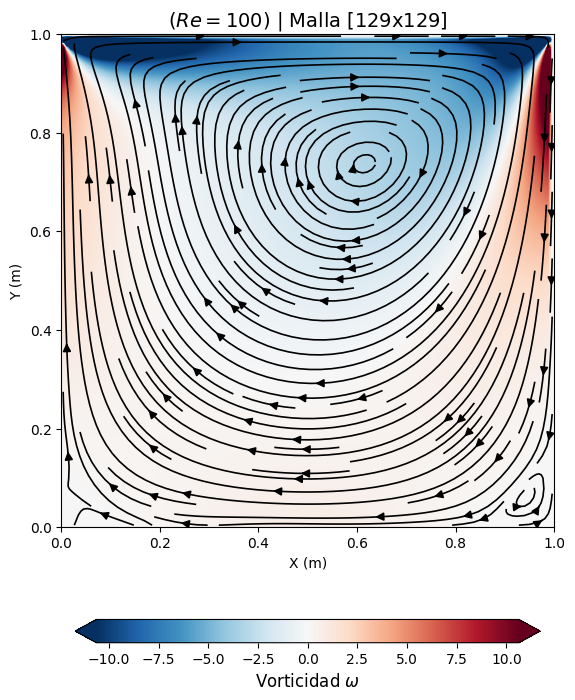

Gráfico estático guardado como: Estacionario_cavidad_Re100.png
Compilando Animacion_cavidad_Re100.mp4 con ffmpeg....
Animación compilada y guardada exitosamente.
Caso concluido y memoria purgada. Avanzando al siguiente caso....


Simulando caso: cavidad con Re = 5000  y Malla: 257x257
Paso 500: Poisson convergió en 35 iteraciones.
  -> Progreso: 1000/50000 pasos temporales computados.
  -> Progreso: 2000/50000 pasos temporales computados.
  -> Progreso: 3000/50000 pasos temporales computados.
  -> Progreso: 4000/50000 pasos temporales computados.
  -> Progreso: 5000/50000 pasos temporales computados.
  -> Progreso: 6000/50000 pasos temporales computados.
  -> Progreso: 7000/50000 pasos temporales computados.
  -> Progreso: 8000/50000 pasos temporales computados.
  -> Progreso: 9000/50000 pasos temporales computados.
  -> Progreso: 10000/50000 pasos temporales computados.
  -> Progreso: 11000/50000 pasos temporales computados.
  -> Progreso: 12000/50000 pasos temporales computados.
  ->

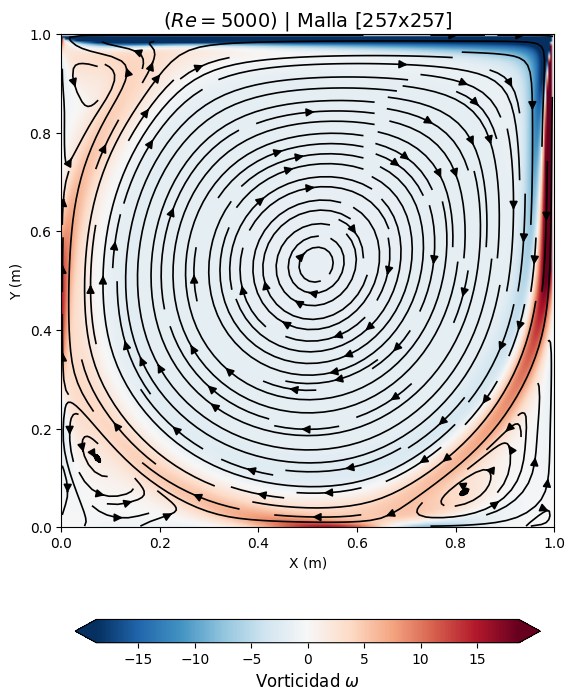

Gráfico estático guardado como: Estacionario_cavidad_Re5000.png
Compilando Animacion_cavidad_Re5000.mp4 con ffmpeg....
Animación compilada y guardada exitosamente.
Caso concluido y memoria purgada. Avanzando al siguiente caso....


Simulando caso: cavidad con Re = 400  y Malla: 129x129
Paso 500: Poisson convergió en 5 iteraciones.
  -> Progreso: 1000/10000 pasos temporales computados.
  -> Progreso: 2000/10000 pasos temporales computados.
  -> Progreso: 3000/10000 pasos temporales computados.
  -> Progreso: 4000/10000 pasos temporales computados.
  -> Progreso: 5000/10000 pasos temporales computados.
  -> Progreso: 6000/10000 pasos temporales computados.
  -> Progreso: 7000/10000 pasos temporales computados.
  -> Progreso: 8000/10000 pasos temporales computados.
  -> Progreso: 9000/10000 pasos temporales computados.
Simulación finalizada exitosamente para CAVIDAD.
Tensores exportados a: Datos_cavidad_Re400.npz


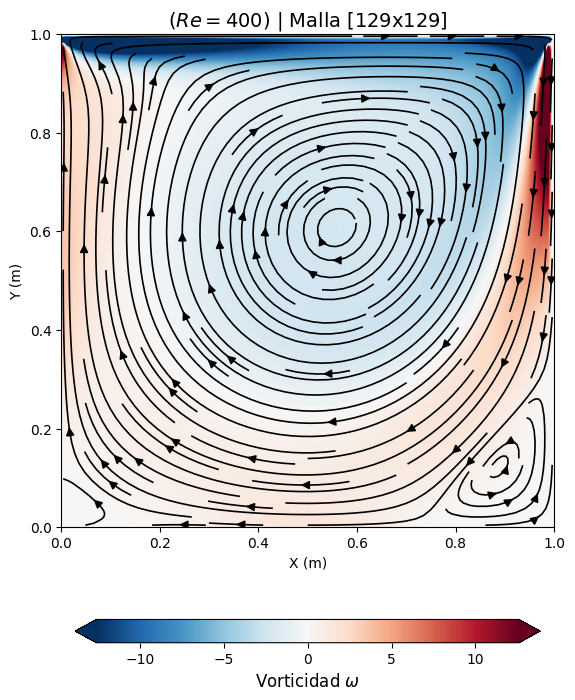

Gráfico estático guardado como: Estacionario_cavidad_Re400.png
Compilando Animacion_cavidad_Re400.mp4 con ffmpeg....
Animación compilada y guardada exitosamente.
Caso concluido y memoria purgada. Avanzando al siguiente caso....


Simulando caso: cavidad con Re = 1000  y Malla: 129x129
Paso 500: Poisson convergió en 15 iteraciones.
  -> Progreso: 1000/15000 pasos temporales computados.
  -> Progreso: 2000/15000 pasos temporales computados.
  -> Progreso: 3000/15000 pasos temporales computados.
  -> Progreso: 4000/15000 pasos temporales computados.
  -> Progreso: 5000/15000 pasos temporales computados.
  -> Progreso: 6000/15000 pasos temporales computados.
  -> Progreso: 7000/15000 pasos temporales computados.
  -> Progreso: 8000/15000 pasos temporales computados.
  -> Progreso: 9000/15000 pasos temporales computados.
  -> Progreso: 10000/15000 pasos temporales computados.
  -> Progreso: 11000/15000 pasos temporales computados.
  -> Progreso: 12000/15000 pasos temporales computados.
  ->

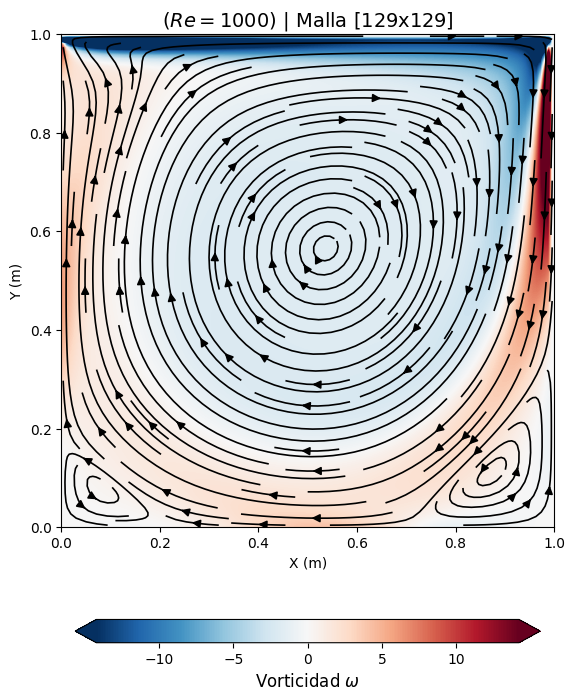

Gráfico estático guardado como: Estacionario_cavidad_Re1000.png
Compilando Animacion_cavidad_Re1000.mp4 con ffmpeg....
Animación compilada y guardada exitosamente.
Caso concluido y memoria purgada. Avanzando al siguiente caso....


Simulando caso: cavidad con Re = 3200  y Malla: 129x129
Paso 500: Poisson convergió en 3 iteraciones.
  -> Progreso: 1000/25000 pasos temporales computados.
  -> Progreso: 2000/25000 pasos temporales computados.
  -> Progreso: 3000/25000 pasos temporales computados.
  -> Progreso: 4000/25000 pasos temporales computados.
  -> Progreso: 5000/25000 pasos temporales computados.
  -> Progreso: 6000/25000 pasos temporales computados.
  -> Progreso: 7000/25000 pasos temporales computados.
  -> Progreso: 8000/25000 pasos temporales computados.
  -> Progreso: 9000/25000 pasos temporales computados.
  -> Progreso: 10000/25000 pasos temporales computados.
  -> Progreso: 11000/25000 pasos temporales computados.
  -> Progreso: 12000/25000 pasos temporales computados.
  -

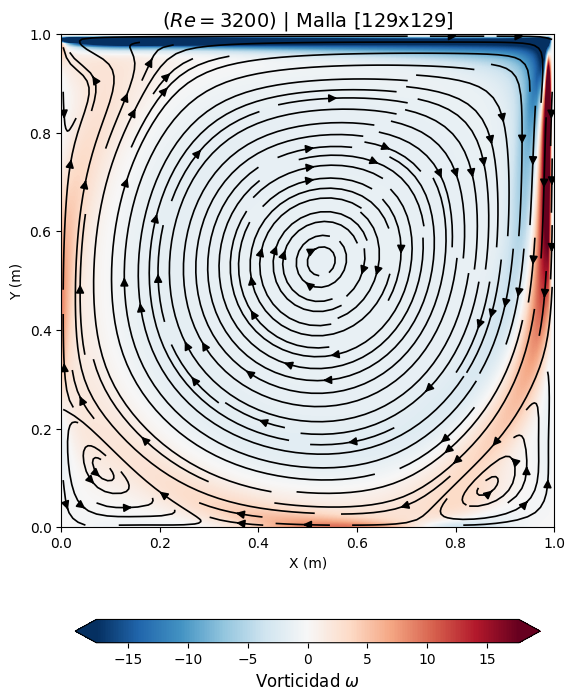

Gráfico estático guardado como: Estacionario_cavidad_Re3200.png
Compilando Animacion_cavidad_Re3200.mp4 con ffmpeg....
Animación compilada y guardada exitosamente.
Caso concluido y memoria purgada. Avanzando al siguiente caso....




In [ ]:
# Configuramos el motor de ejecución modular mencionado en el inicio para el estudio sistemático de los diferentes casos físicos. 
# El ciclo itera sobre una lista de diccionarios que definen de forma independiente las propiedades numéricas, reológicas y geométricas de cada caso. 
# La celda empaqueta de forma comprimida los resultados masivos en archivos binarios .npz 
# esto para la posterior comparación con los resultados de Ghia et al. además sirve de seguro ante cualquier problema de convergencia o saturación de memoria al simular mallas más densas
# y Re más altos. Posterior se generan y guardan los gráficos y animaciones para cada caso y finalmente, como se mencionó antes, mediante el módulo gc que funciona como recolector de basura en Python
# se purga la memoria para liberar RAM antes de iniciar la siguiente simulación.
 
# Se definen la lista con los diccionarios para los casos de interés (añadir aquí más casos para ver la transición laminar-turbulenta en la cavidad, ghia et al. considera Re = 100, 400, 1000, 3200 y 5000)

casos_estudio = [

    {
        'Re': 100,
        'geometria': 'cavidad',
        'nt': 15000,
        'dt': 0.001,
        'imax': 129,
        'jmax': 129,
        'Lx': 1.0,
        'Ly': 1.0,
        'u_ref': 1.0,
        'gamma': 0.1,
        'omega_sor': 1.92,
        'eps': 0.005,
       'iter_max': 3000,
        'paso_guardado': 20
    },
    {
        'Re': 5000,
        'geometria': 'cavidad',
        'nt': 50000,   
        'dt': 0.002,  
        'imax': 257,   
        'jmax': 257,
        'Lx': 1.0,
        'Ly': 1.0,
        'u_ref': 1.0,
        'gamma': 0.2,
        'omega_sor': 1.97,
        'eps': 0.01,
        'iter_max': 6000,
        'paso_guardado': 200 
    },
    {
        'Re': 400,
        'geometria': 'cavidad',
        'nt': 10000,
        'dt': 0.002,
        'imax': 129,
        'jmax': 129,
        'Lx': 1.0,
        'Ly': 1.0,
        'u_ref': 1.0,
        'gamma': 0.2,
        'omega_sor': 1.90,
        'eps': 0.001,
       'iter_max': 3000,
        'paso_guardado': 100
    },
    {
        'Re': 1000,
        'geometria': 'cavidad',
        'nt': 15000,
        'dt': 0.002,
        'imax': 129,
        'jmax': 129,
        'Lx': 1.0,
        'Ly': 1.0,
        'u_ref': 1.0,
        'gamma': 0.4,
        'omega_sor': 1.90,
        'eps': 0.001,
       'iter_max': 4000,
        'paso_guardado': 100
    },
    {
        'Re': 3200,
        'geometria': 'cavidad',
        'nt': 25000,
        'dt': 0.002,
        'imax': 129,
        'jmax': 129,
        'Lx': 1.0,
        'Ly': 1.0,
        'u_ref': 1.0,
        'gamma': 0.6,
        'omega_sor': 1.90,
        'eps': 0.001,
       'iter_max': 5000,
        'paso_guardado': 100
    },
    {
        'Re': 1200,
        'geometria': 'obstaculo',
        'nt': 20000,
        'dt': 0.001,
        'imax': 240,
        'jmax': 80,
        'Lx': 3.0,
        'Ly': 1.0,
        'u_ref': 1.0,
        'gamma': 0.01,
        'omega_sor': 1.97,
        'eps': 0.001,
        'iter_max': 3000,
        'paso_guardado': 50
    }
    
]

# Ciclo principal de ejecución modular para cada caso de estudio definido en la lista de diccionarios. Se imprime un mensaje al inicio de cada simulación para monitorear el progreso y los parámetros del caso actual.
for iteracion, caso in enumerate(casos_estudio): 
    R = caso['Ly'] / 8  

    print(f"Simulando caso: {caso['geometria']} con Re = {caso['Re'] if caso['geometria'] == 'cavidad' else caso['Re'] * (2*R/caso['Lx'])}  y Malla: {caso['imax']}x{caso['jmax']}")

    dx = caso['Lx'] / caso['imax']
    dy = caso['Ly'] / caso['jmax']
    
    u, v, p, hist_u, hist_v, hist_w = simular_navier_stokes(
        Re=caso['Re'],
        geometria=caso['geometria'],
        nt=caso['nt'],
        dt=caso['dt'],
        imax=caso['imax'],
        jmax=caso['jmax'],
        Lx=caso['Lx'],
        Ly=caso['Ly'],
        u_ref=caso['u_ref'],
        gamma=caso['gamma'],
        omega=caso['omega_sor'], 
        eps=caso['eps'],
        iter_max=caso['iter_max'],
        paso_guardado=caso['paso_guardado']
    )
    
    # Empaquetamiento binario comprimido (.npz) para posterior análisis cuantitativo con los resultados de Ghia et al.
    archivo_npz = f"Datos_{caso['geometria']}_Re{int(caso['Re'] if caso['geometria'] == 'cavidad' else caso['Re'] * (2*R/caso['Lx']))}.npz"
    np.savez_compressed(
        archivo_npz,
        u_final=u,
        v_final=v,
        p_final=p,
        historial_u=hist_u,
        historial_v=hist_v,
        historial_vorticidad=hist_w,
        parametros=caso
    )
    print(f"Tensores exportados a: {archivo_npz}")
    
    # Generación de elementos visuales para análisis y presentación de resultados.
    generar_graficos_estaticos(
        u=u,
        v=v,
        historial_vorticidad=hist_w,
        Re=caso['Re'] if caso['geometria'] == 'cavidad' else caso['Re'] * (2*R/caso['Lx']),
        geometria=caso['geometria'],
        Lx=caso['Lx'],
        Ly=caso['Ly'],
        imax=caso['imax'],
        jmax=caso['jmax'],
        dx=dx,
        dy=dy
    )
    
    exportar_animacion(
        historial_u=hist_u,
        historial_v=hist_v,
        historial_vorticidad=hist_w,
        Re=caso['Re'] if caso['geometria'] == 'cavidad' else caso['Re'] * (2*R/caso['Lx']),
        geometria=caso['geometria'],
        Lx=caso['Lx'],
        Ly=caso['Ly'],
        imax=caso['imax'],
        jmax=caso['jmax'],
        dx=dx,
        dy=dy
    )
    
    # Purgado de memoria para liberar RAM.
    del u, v, p, hist_u, hist_v, hist_w
    gc.collect()
    
    print(f"Caso concluido y memoria purgada. Avanzando al siguiente caso....\n\n")